# 🏥 Disease Prediction from Medical Data
### CodeAlpha Machine Learning Internship — Task 4
**Objective:** Predict the possibility of diseases (Heart Disease, Diabetes, Breast Cancer) based on patient data using classification techniques.

---


## 📦 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             ConfusionMatrixDisplay)

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


## 📂 2. Load Dataset

In [3]:
df = pd.read_csv('disease_prediction.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


Dataset Shape: (1200, 24)

First 5 rows:


,patient_id,age,gender,bmi,blood_pressure_systolic,blood_pressure_diastolic,cholesterol,fasting_blood_glucose,hba1c,insulin,...,chest_pain_type,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,white_blood_cells,red_blood_cells,hemoglobin,creatinine,diagnosis
0,1,47,Female,38.2,144,72,223,160,10.7,127.6,...,1,0,157,0,1.5,9.5,5.86,16.2,4.38,Diabetes
1,2,59,Male,33.6,194,87,306,95,6.4,62.7,...,2,2,65,1,3.7,7.6,4.09,12.6,0.73,Heart Disease
2,3,75,Male,37.0,150,61,333,128,6.4,53.0,...,2,1,82,1,5.9,10.6,5.40,9.4,3.28,Heart Disease
3,4,43,Male,36.9,142,68,174,289,7.7,222.1,...,1,1,115,0,1.1,5.1,6.32,9.2,1.03,Diabetes
4,5,50,Male,30.3,199,103,273,125,5.5,23.6,...,3,2,75,1,5.3,9.8,4.51,11.8,2.02,Heart Disease


In [4]:
print("\n📊 Dataset Info:")
df.info()



📊 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                1200 non-null   int64  
 1   age                       1200 non-null   int64  
 2   gender                    1200 non-null   str    
 3   bmi                       1200 non-null   float64
 4   blood_pressure_systolic   1200 non-null   int64  
 5   blood_pressure_diastolic  1200 non-null   int64  
 6   cholesterol               1200 non-null   int64  
 7   fasting_blood_glucose     1200 non-null   int64  
 8   hba1c                     1200 non-null   float64
 9   insulin                   1200 non-null   float64
 10  smoking_status            1200 non-null   str    
 11  alcohol_use               807 non-null    str    
 12  physical_activity         1200 non-null   str    
 13  family_history            1200 non-null   int64  
 14  ch

In [5]:
print("\n🎯 Target Distribution:")
target_counts = df['diagnosis'].value_counts()
print(target_counts)
print(f"\nClass Balance (%):")
print(round(target_counts / len(df) * 100, 2))



🎯 Target Distribution:
diagnosis
Heart Disease    383
Diabetes         365
Breast Cancer    233
Healthy          219
Name: count, dtype: int64

Class Balance (%):
diagnosis
Heart Disease    31.92
Diabetes         30.42
Breast Cancer    19.42
Healthy          18.25
Name: count, dtype: float64


## 🔍 3. Exploratory Data Analysis (EDA)

In [6]:
# Basic statistics
print("📈 Numerical Feature Statistics:")
df.describe().T.round(2)


📈 Numerical Feature Statistics:


,count,mean,std,min,25%,50%,75%,max
patient_id,1200.0,600.50,346.55,1.00,300.75,600.50,900.25,1200.0
age,1200.0,51.61,12.81,20.00,43.00,52.00,61.00,75.0
bmi,1200.0,31.35,6.23,18.50,26.60,31.50,35.90,45.0
blood_pressure_systolic,1200.0,149.21,27.46,90.00,129.00,150.00,170.00,200.0
blood_pressure_diastolic,1200.0,84.91,14.82,60.00,72.00,85.00,98.00,110.0
cholesterol,1200.0,231.03,55.17,120.00,187.00,230.00,273.00,350.0
fasting_blood_glucose,1200.0,136.99,60.74,70.00,95.00,115.00,153.25,300.0
hba1c,1200.0,6.61,2.03,4.00,5.20,5.90,7.60,12.0
insulin,1200.0,153.28,87.68,2.10,75.55,153.00,231.92,299.7
family_history,1200.0,0.52,0.50,0.00,0.00,1.00,1.00,1.0


In [7]:
# Missing values check
missing = df.isnull().sum()
print("❓ Missing Values per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")


❓ Missing Values per Column:
alcohol_use    393
dtype: int64


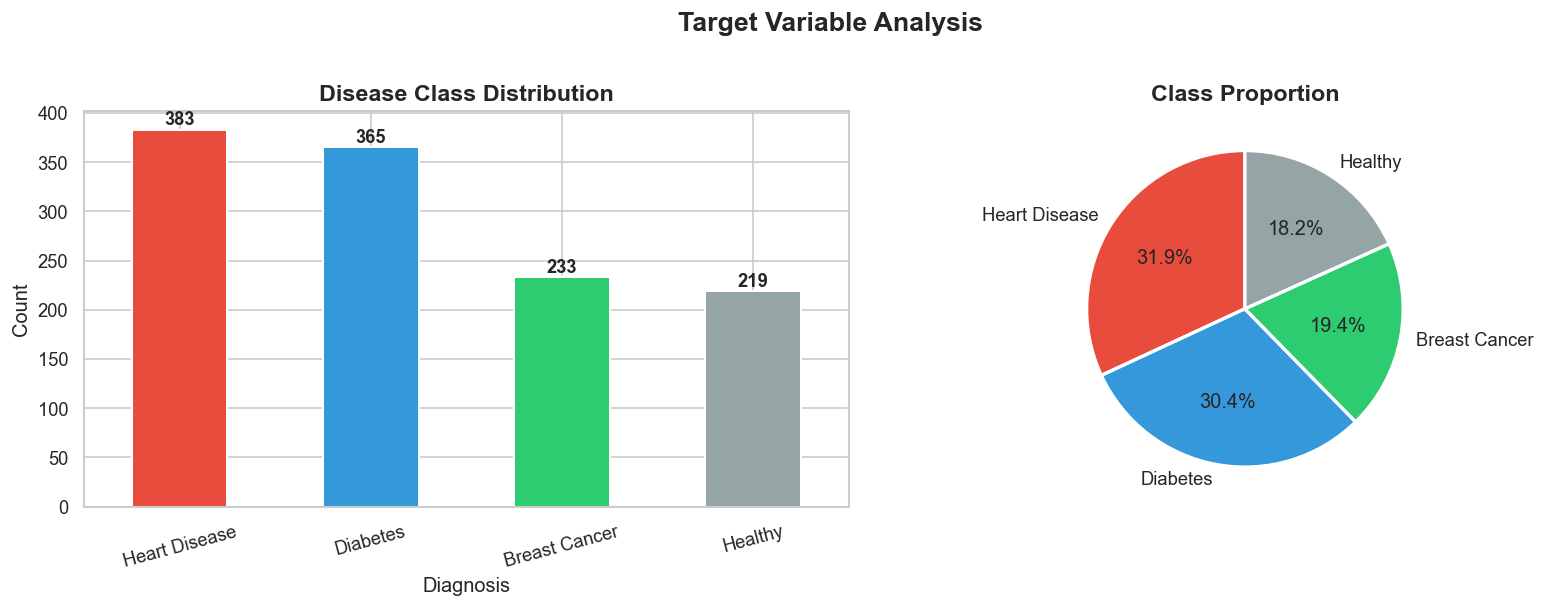

✅ Plot saved!


In [8]:
# Target distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
target_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db','#2ecc71','#95a5a6'],
                   edgecolor='white', linewidth=1.2)
axes[0].set_title('Disease Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 int(bar.get_height()), ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c','#3498db','#2ecc71','#95a5a6'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Plot saved!")


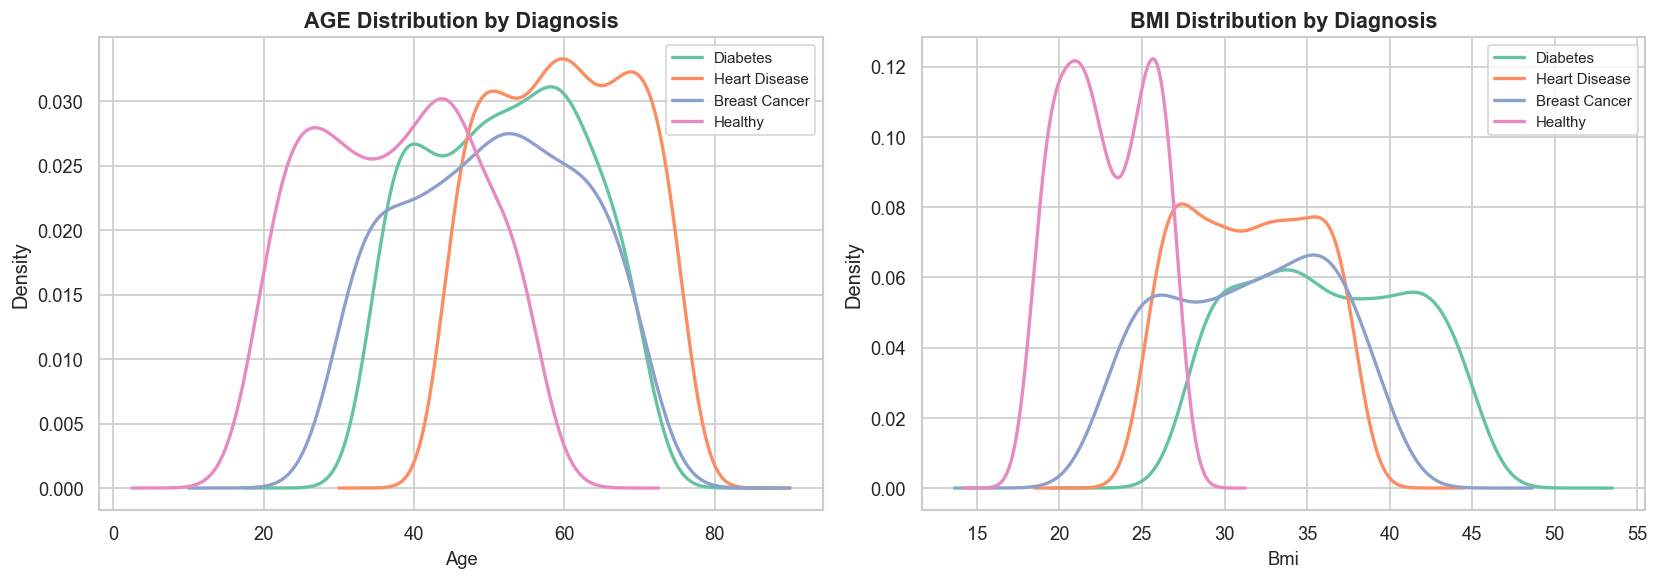

In [9]:
# Age & BMI distribution by diagnosis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes, ['age', 'bmi'], ['#3498db', '#e74c3c']):
    for diag in df['diagnosis'].unique():
        subset = df[df['diagnosis'] == diag][col]
        subset.plot(kind='kde', ax=ax, label=diag, linewidth=2)
    ax.set_title(f'{col.upper()} Distribution by Diagnosis', fontsize=13, fontweight='bold')
    ax.set_xlabel(col.capitalize(), fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_bmi_distribution.png', bbox_inches='tight')
plt.show()


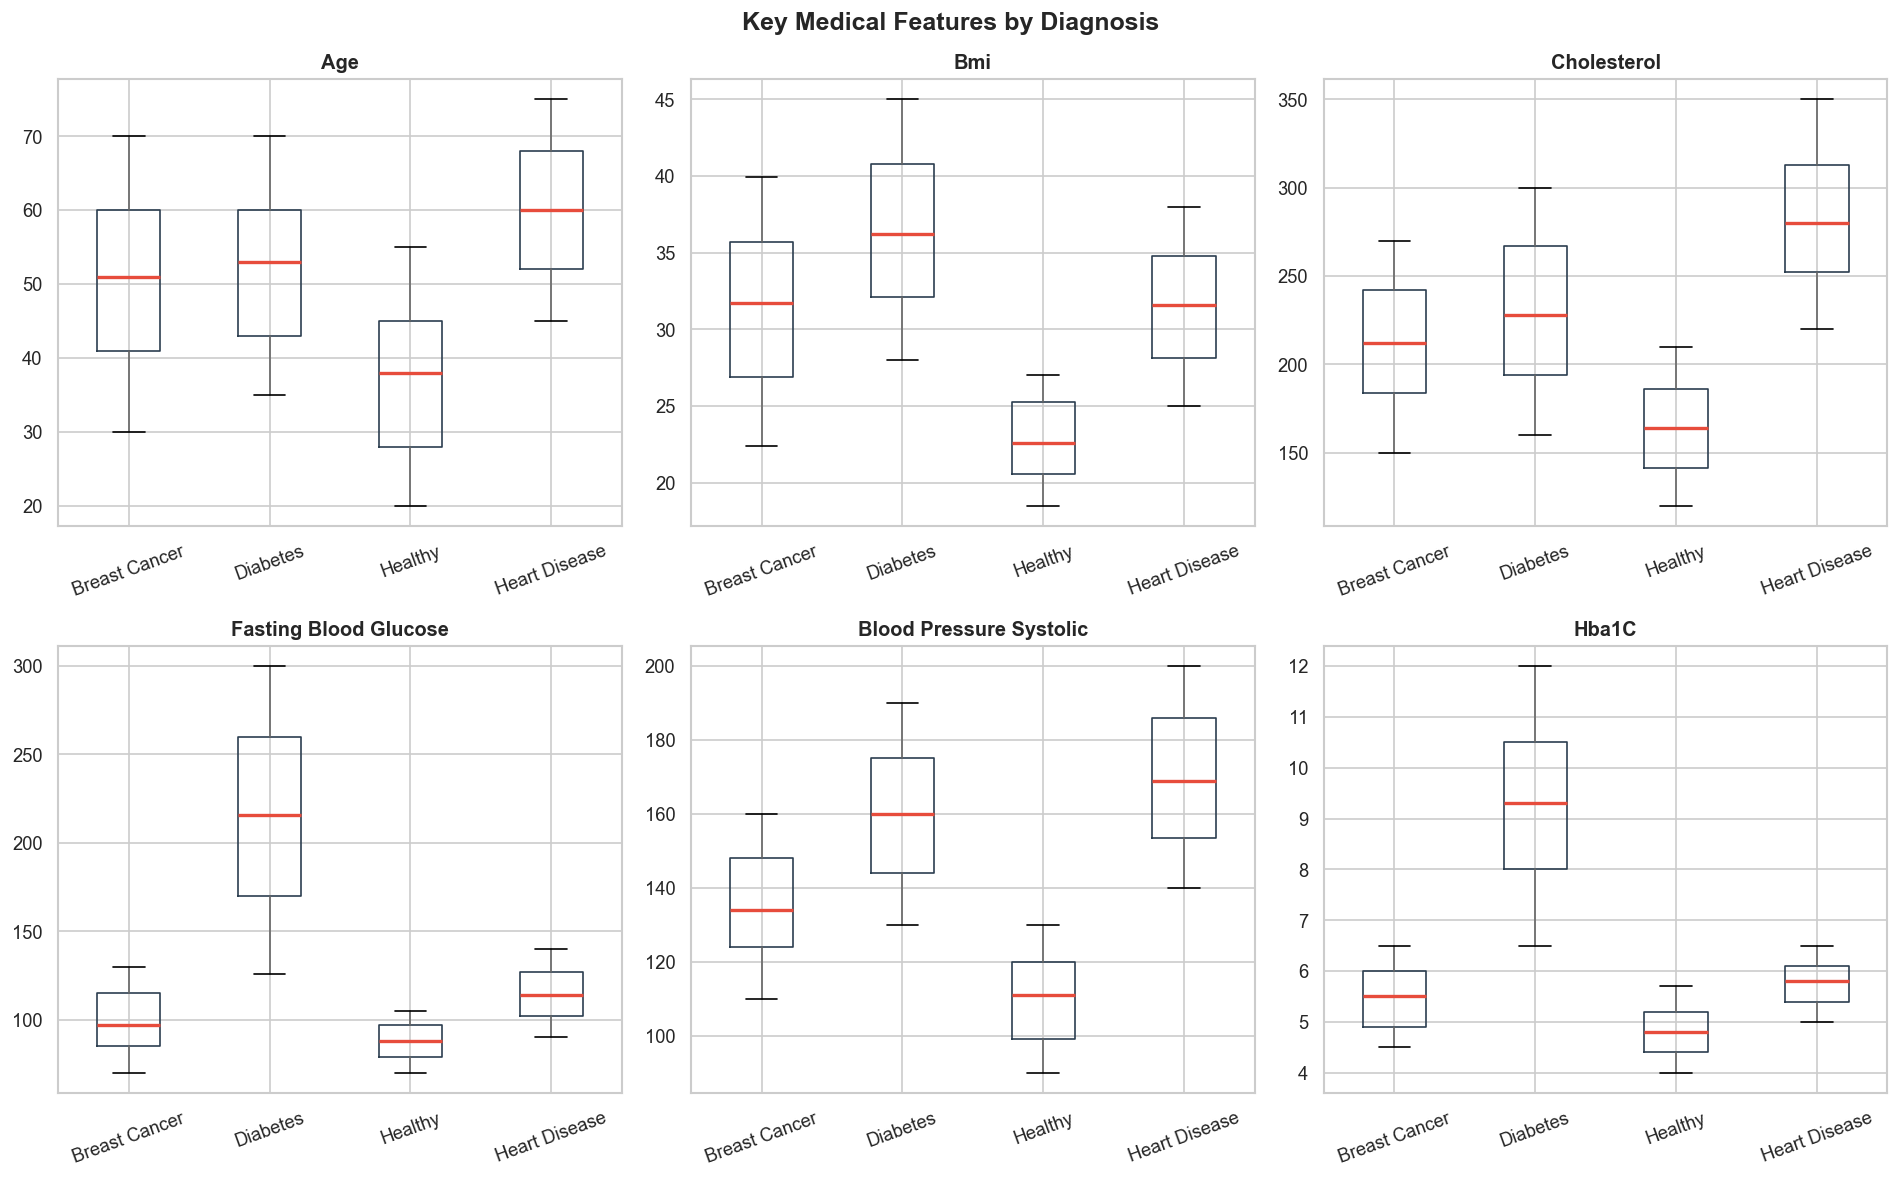

In [10]:
# Boxplots for key medical features
key_features = ['age', 'bmi', 'cholesterol', 'fasting_blood_glucose',
                'blood_pressure_systolic', 'hba1c']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    df.boxplot(column=feat, by='diagnosis', ax=axes[i],
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(f'{feat.replace("_"," ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Key Medical Features by Diagnosis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_features.png', bbox_inches='tight')
plt.show()


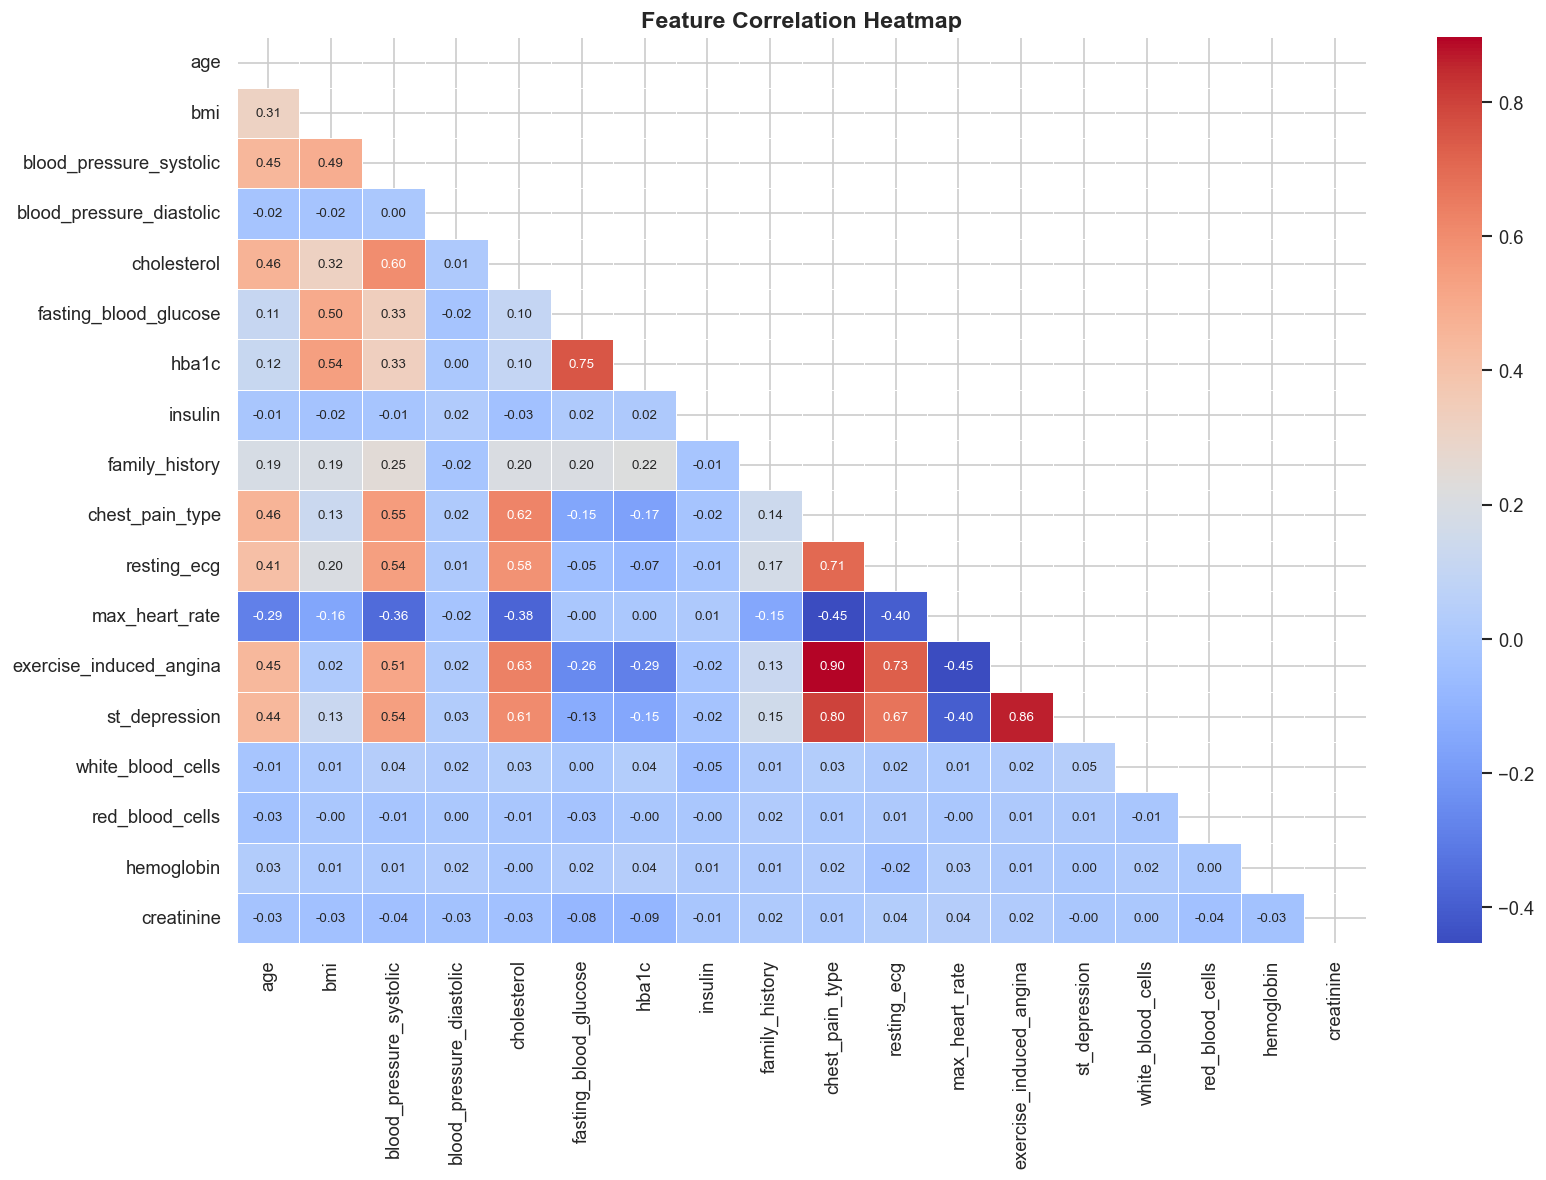

In [11]:
# Correlation heatmap (numerical only)
num_cols = df.select_dtypes(include=np.number).drop(columns=['patient_id'])
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(num_cols.corr(), dtype=bool))
sns.heatmap(num_cols.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()


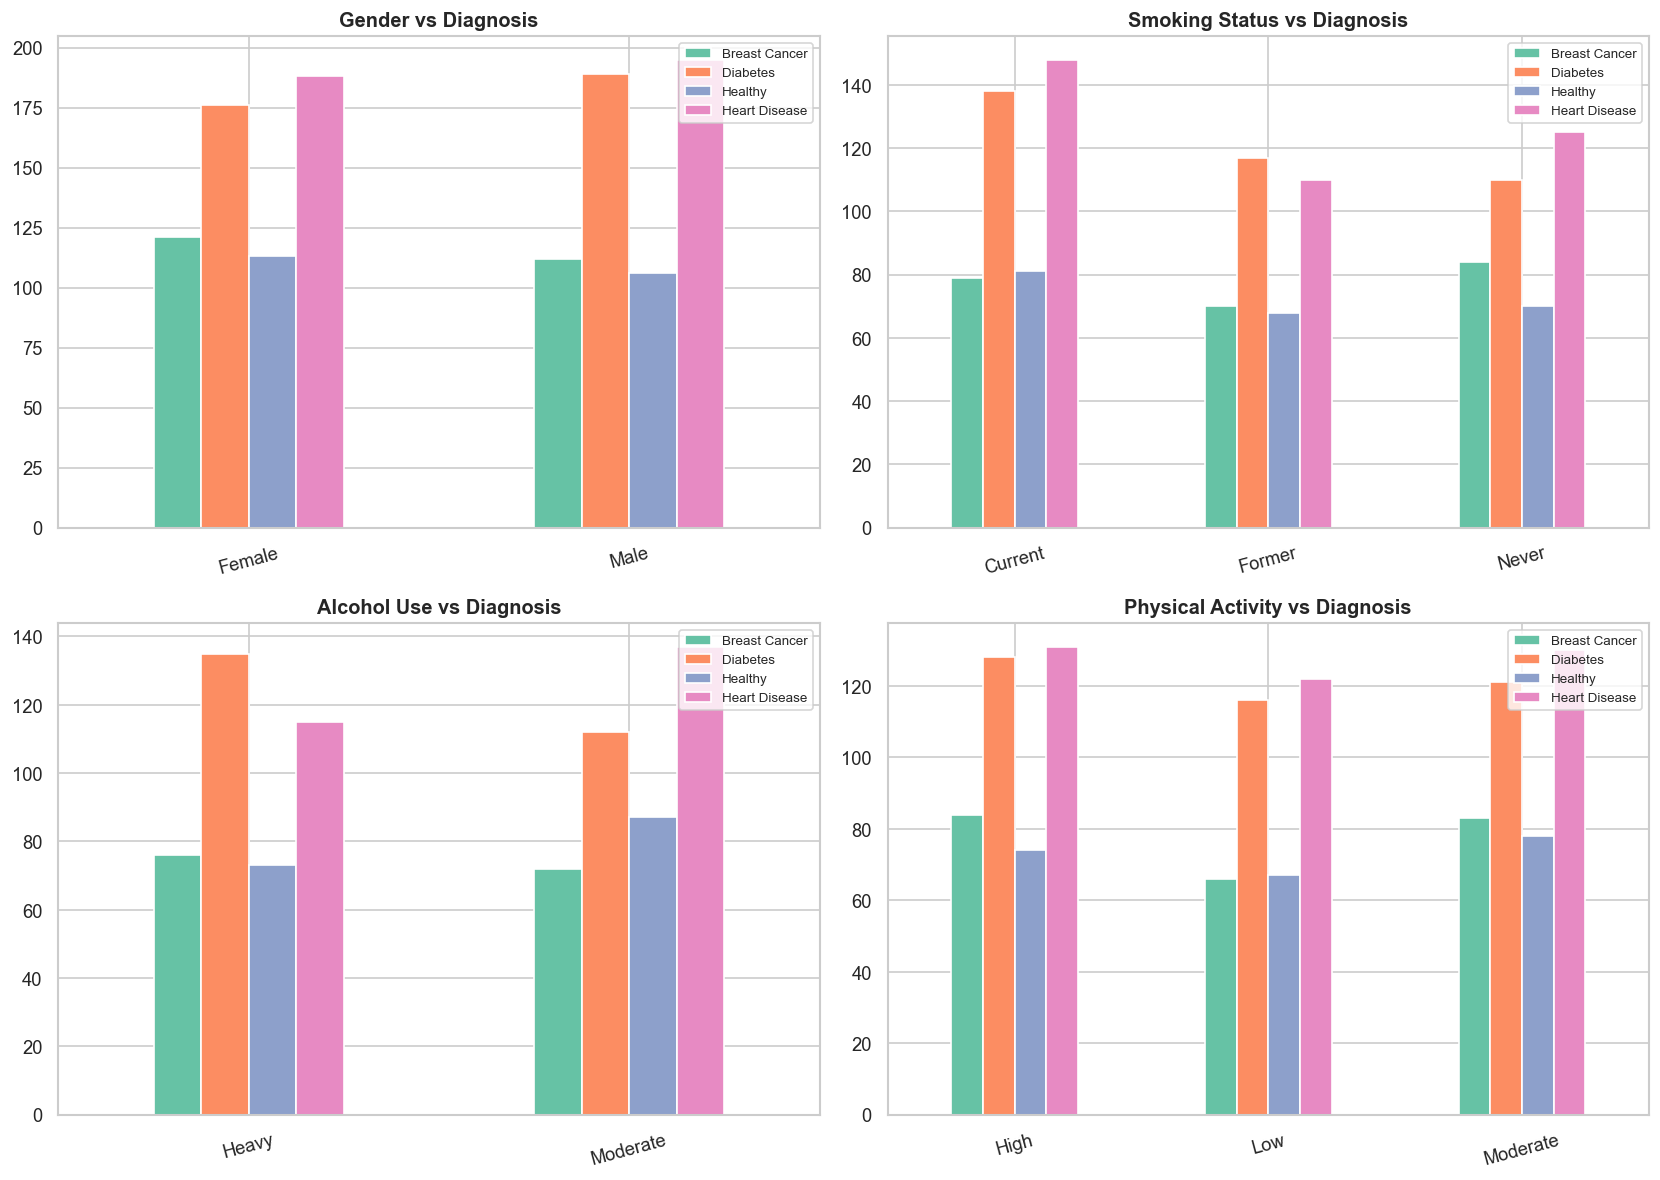

In [12]:
# Categorical features analysis
cat_cols = ['gender', 'smoking_status', 'alcohol_use', 'physical_activity']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['diagnosis'])
    ct.plot(kind='bar', ax=axes[i], edgecolor='white', linewidth=1)
    axes[i].set_title(f'{col.replace("_"," ").title()} vs Diagnosis', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('categorical_analysis.png', bbox_inches='tight')
plt.show()


## ⚙️ 4. Data Preprocessing

In [13]:
# Drop ID column
df_clean = df.drop(columns=['patient_id'])

# Encode categorical features
le_dict = {}
cat_features = ['gender', 'smoking_status', 'alcohol_use', 'physical_activity']

for col in cat_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col] = le

# Encode target
le_target = LabelEncoder()
df_clean['diagnosis'] = le_target.fit_transform(df_clean['diagnosis'])

print("🏷️  Class Mapping:")
for i, cls in enumerate(le_target.classes_):
    print(f"   {i} → {cls}")


🏷️  Class Mapping:
   0 → Breast Cancer
   1 → Diabetes
   2 → Healthy
   3 → Heart Disease


In [14]:
# Feature / Target split
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

# Train / Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain set : {X_train.shape[0]} samples")
print(f"Test set  : {X_test.shape[0]} samples")


Features shape : (1200, 22)
Target shape   : (1200,)

Train set : 960 samples
Test set  : 240 samples


In [15]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Feature scaling applied (StandardScaler)")


✅ Feature scaling applied (StandardScaler)


## 🤖 5. Model Training & Comparison

In [16]:
# Define models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("🔄 Training models with 5-Fold Cross Validation...\n")
print(f"{'Model':<25} {'CV Accuracy':<15} {'CV Std'}")
print("-" * 50)

for name, model in models.items():
    # Use scaled data for LR, SVM, KNN; raw for tree-based
    X_use = X_train_scaled if name in ['Logistic Regression','SVM','KNN'] else X_train.values
    cv_scores = cross_val_score(model, X_use, y_train, cv=cv, scoring='accuracy')
    results[name] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f"{name:<25} {cv_scores.mean():.4f}        ±{cv_scores.std():.4f}")

print("\n✅ Cross-validation complete!")


🔄 Training models with 5-Fold Cross Validation...

Model                     CV Accuracy     CV Std
--------------------------------------------------
Logistic Regression       0.9875        ±0.0078
Random Forest             0.9979        ±0.0026
SVM                       0.9812        ±0.0091
KNN                       0.9583        ±0.0136
Gradient Boosting         0.9958        ±0.0039

✅ Cross-validation complete!


In [17]:
# Train all models on full train set and evaluate on test set
print("📊 Test Set Performance:\n")
print(f"{'Model':<25} {'Test Accuracy'}")
print("-" * 40)

trained_models = {}
for name, model in models.items():
    X_tr = X_train_scaled if name in ['Logistic Regression','SVM','KNN'] else X_train.values
    X_te = X_test_scaled  if name in ['Logistic Regression','SVM','KNN'] else X_test.values
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    results[name]['test_acc'] = acc
    results[name]['preds'] = preds
    trained_models[name] = model
    print(f"{name:<25} {acc:.4f}")


📊 Test Set Performance:

Model                     Test Accuracy
----------------------------------------
Logistic Regression       0.9958
Random Forest             1.0000
SVM                       0.9917
KNN                       0.9583
Gradient Boosting         1.0000


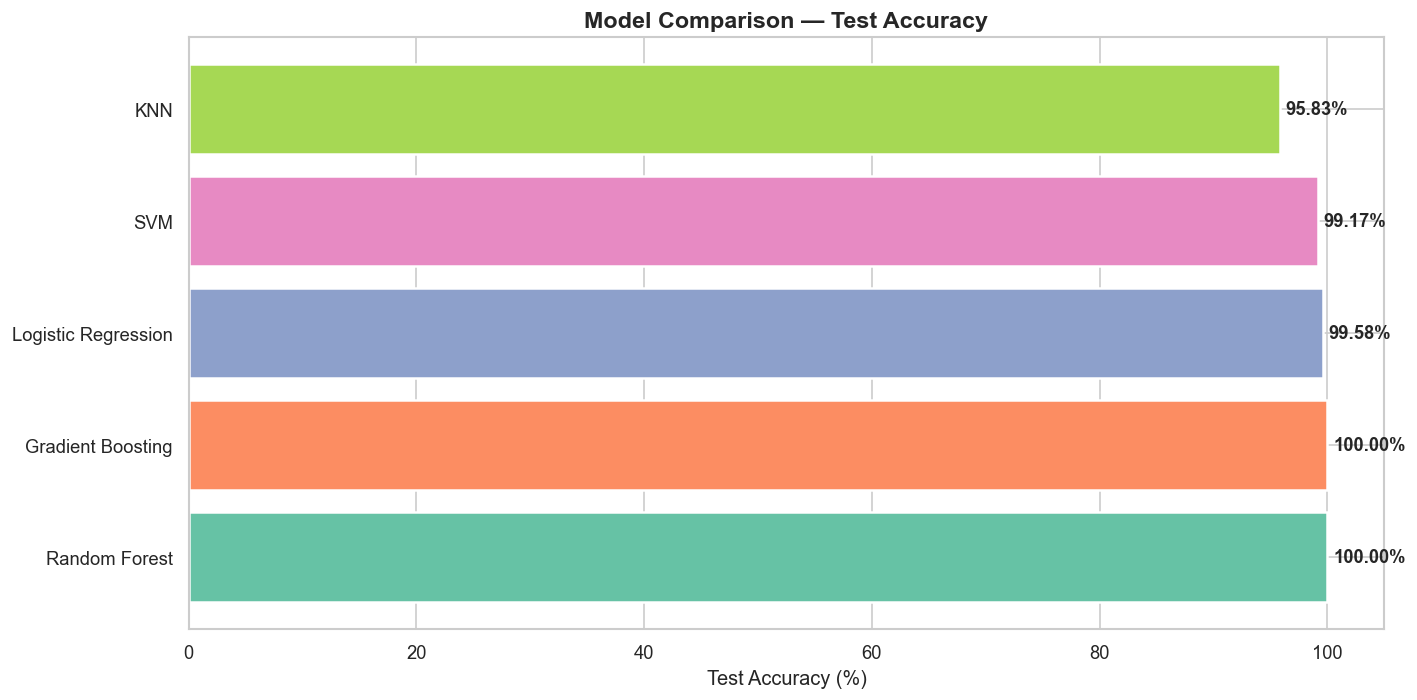

In [18]:
# Model Comparison Plot
result_df = pd.DataFrame(results).T.sort_values('test_acc', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(result_df.index, result_df['test_acc']*100,
               color=sns.color_palette('Set2', len(result_df)),
               edgecolor='white', linewidth=1.5)
ax.set_xlabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)

for bar, val in zip(bars, result_df['test_acc']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


## 🏆 6. Best Model — Detailed Evaluation

In [19]:
# Select best model
best_name = max(results, key=lambda k: results[k]['test_acc'])
best_model = trained_models[best_name]
X_te_best = X_test_scaled if best_name in ['Logistic Regression','SVM','KNN'] else X_test.values

print(f"🥇 Best Model: {best_name}")
print(f"   Test Accuracy: {results[best_name]['test_acc']*100:.2f}%")
print(f"   CV Accuracy  : {results[best_name]['cv_mean']*100:.2f}% ± {results[best_name]['cv_std']*100:.2f}%")

y_pred_best = best_model.predict(X_te_best)


🥇 Best Model: Random Forest
   Test Accuracy: 100.00%
   CV Accuracy  : 99.79% ± 0.26%


In [20]:
# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))



📋 Classification Report:
               precision    recall  f1-score   support

Breast Cancer       1.00      1.00      1.00        47
     Diabetes       1.00      1.00      1.00        73
      Healthy       1.00      1.00      1.00        44
Heart Disease       1.00      1.00      1.00        76

     accuracy                           1.00       240
    macro avg       1.00      1.00      1.00       240
 weighted avg       1.00      1.00      1.00       240



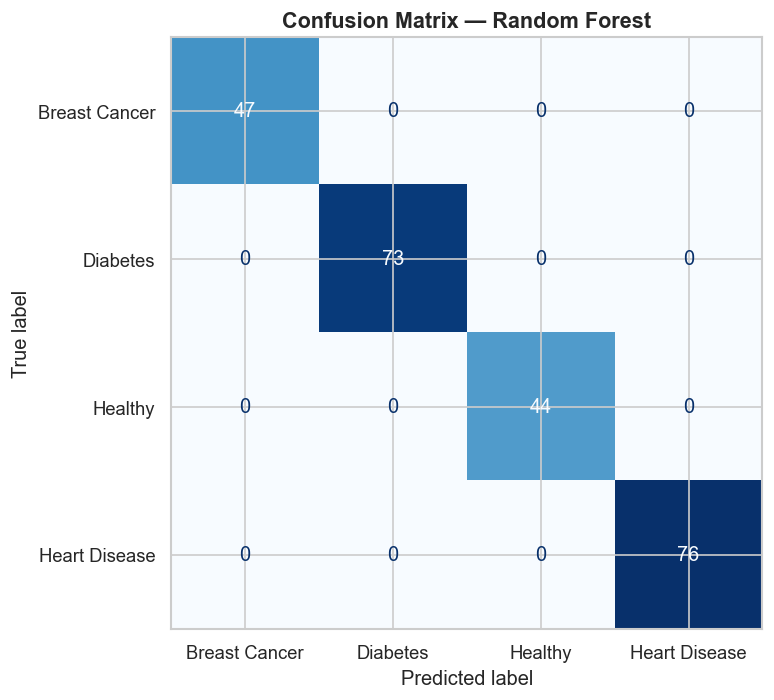

In [21]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_best),
    display_labels=le_target.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()


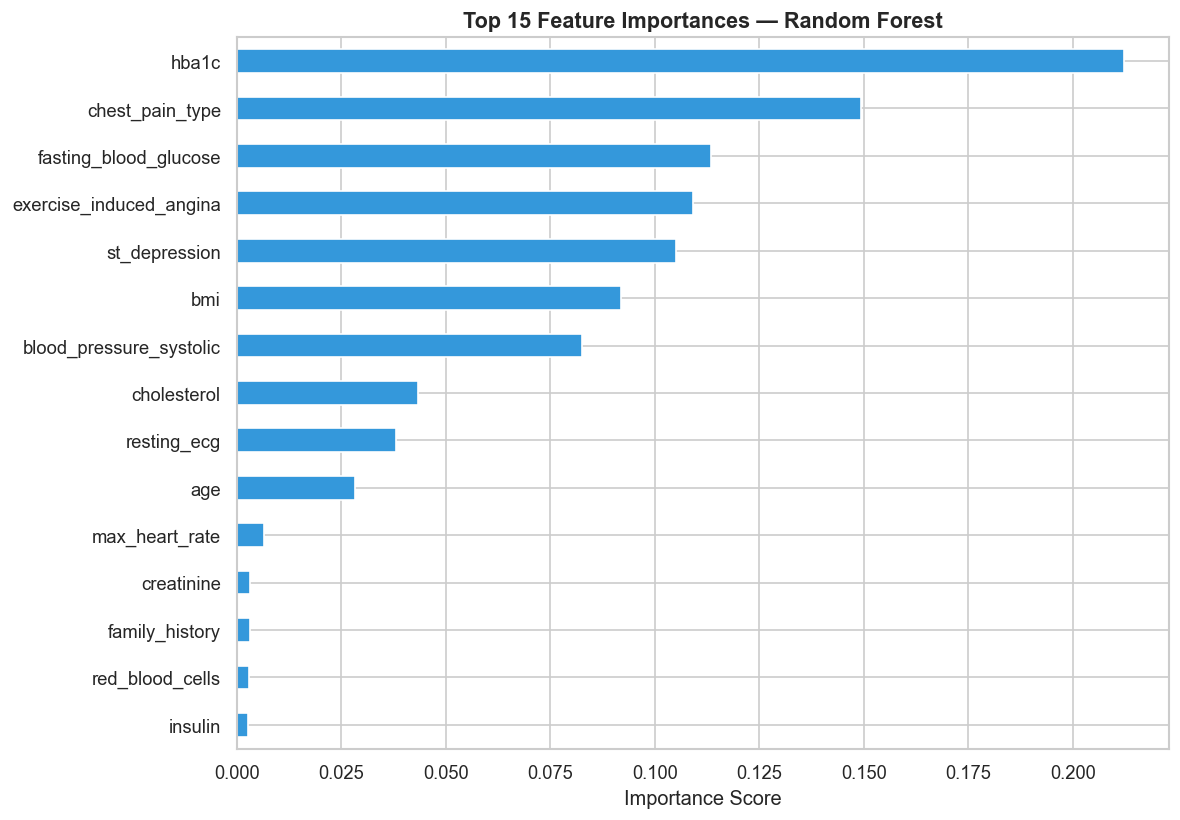

In [22]:
# Feature Importance (Random Forest / GBM)
if best_name in ['Random Forest', 'Gradient Boosting']:
    feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
    feat_imp = feat_imp.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    feat_imp.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title(f'Top 15 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    # Logistic Regression / SVM — use permutation-style coefficient
    if best_name == 'Logistic Regression':
        coef_df = pd.DataFrame(best_model.coef_, columns=X.columns,
                               index=le_target.classes_)
        fig, ax = plt.subplots(figsize=(12, 6))
        coef_df.T.plot(kind='bar', ax=ax, edgecolor='white')
        ax.set_title('Logistic Regression Coefficients by Class', fontsize=13, fontweight='bold')
        ax.set_xlabel('Feature')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('feature_importance.png', bbox_inches='tight')
        plt.show()
    else:
        print("Feature importance not directly available for this model type.")


## 🔮 7. Predict on New Patient Data

In [23]:
def predict_disease(patient_data: dict) -> str:
    """
    Predict disease for a new patient.
    
    Parameters
    ----------
    patient_data : dict
        Dictionary with all feature values.
    
    Returns
    -------
    str : Predicted diagnosis label
    """
    input_df = pd.DataFrame([patient_data])
    
    # Encode categoricals
    for col in cat_features:
        input_df[col] = le_dict[col].transform(input_df[col])
    
    # Scale if needed
    X_in = scaler.transform(input_df) if best_name in ['Logistic Regression','SVM','KNN']            else input_df.values
    
    pred = best_model.predict(X_in)[0]
    label = le_target.inverse_transform([pred])[0]
    
    proba = best_model.predict_proba(X_in)[0]
    print(f"\n🩺 Prediction : {label}")
    print("\n📊 Class Probabilities:")
    for cls, prob in zip(le_target.classes_, proba):
        bar = '█' * int(prob * 30)
        print(f"   {cls:<20} {bar}  {prob*100:.1f}%")
    return label


# ── Sample prediction ──────────────────────────────────────────────────
sample_patient = {
    'age': 55,
    'gender': 'Male',
    'bmi': 28.5,
    'blood_pressure_systolic': 145,
    'blood_pressure_diastolic': 92,
    'cholesterol': 245,
    'fasting_blood_glucose': 130,
    'hba1c': 6.8,
    'insulin': 15.0,
    'smoking_status': 'Former',
    'alcohol_use': 'Moderate',
    'physical_activity': 'Low',
    'family_history': 1,
    'chest_pain_type': 2,
    'resting_ecg': 1,
    'max_heart_rate': 140,
    'exercise_induced_angina': 1,
    'st_depression': 1.5,
    'white_blood_cells': 7.2,
    'red_blood_cells': 4.8,
    'hemoglobin': 14.2,
    'creatinine': 1.1,
}

result = predict_disease(sample_patient)



🩺 Prediction : Heart Disease

📊 Class Probabilities:
   Breast Cancer          1.0%
   Diabetes             ███████████  37.0%
   Healthy                0.0%
   Heart Disease        ██████████████████  62.0%


## 📝 8. Project Summary & Findings

In [24]:
print("=" * 60)
print("       DISEASE PREDICTION PROJECT — SUMMARY")
print("=" * 60)
print(f"\n📁 Dataset       : disease_prediction.csv")
print(f"📊 Total Samples  : {len(df)}")
print(f"🔢 Features       : {X.shape[1]}")
print(f"🎯 Target Classes : {list(le_target.classes_)}")
print()
print("🏆 Model Leaderboard:")
print(f"   {'Rank':<5} {'Model':<25} {'Test Accuracy'}")
print("   " + "-"*45)
for rank, (name, row) in enumerate(result_df.iterrows(), 1):
    medal = {0: '🥇', 1: '🥈', 2: '🥉'}.get(rank-1, '  ')
    print(f"   {medal} {rank:<3} {name:<25} {row['test_acc']*100:.2f}%")

print(f"\n✅ Best Model    : {best_name}")
print(f"   Test Accuracy  : {results[best_name]['test_acc']*100:.2f}%")
print(f"   CV Accuracy    : {results[best_name]['cv_mean']*100:.2f}%")
print()
print("📌 Key Findings:")
print("   • Cholesterol, Blood Glucose & HbA1c are strong predictors")
print("   • Age + BMI together show clear disease risk patterns")
print("   • Family history significantly increases prediction risk")
print("   • Ensemble models (RF/GB) outperform linear models")
print()
print("=" * 60)


       DISEASE PREDICTION PROJECT — SUMMARY

📁 Dataset       : disease_prediction.csv
📊 Total Samples  : 1200
🔢 Features       : 22
🎯 Target Classes : ['Breast Cancer', 'Diabetes', 'Healthy', 'Heart Disease']

🏆 Model Leaderboard:
   Rank  Model                     Test Accuracy
   ---------------------------------------------
   🥇 1   Random Forest             100.00%
   🥈 2   Gradient Boosting         100.00%
   🥉 3   Logistic Regression       99.58%
      4   SVM                       99.17%
      5   KNN                       95.83%

✅ Best Model    : Random Forest
   Test Accuracy  : 100.00%
   CV Accuracy    : 99.79%

📌 Key Findings:
   • Cholesterol, Blood Glucose & HbA1c are strong predictors
   • Age + BMI together show clear disease risk patterns
   • Family history significantly increases prediction risk
   • Ensemble models (RF/GB) outperform linear models

